# Modelado y Evaluacion - Video Games Sales

**Segunda Evidencia: Modelado y Evaluacion (Regresion)**

Este notebook continua el trabajo de `analisis_exploratorio.ipynb` (Fase 1). A partir de las
conclusiones de ese EDA, se entrena y evalua un modelo de **regresion** que predice `global_sales`
(ventas globales en millones de copias) a partir de la recepcion critica/de usuarios y otras
caracteristicas del juego disponibles en el dataset.

## Por que regresion y no clasificacion

`global_sales` es una variable numerica continua, no una categoria: el problema natural es predecir
un numero (millones de copias vendidas), no una clase. El EDA ya habia explorado de forma descriptiva
la relacion entre `critic_score` y `global_sales` (rangos de puntaje vs. venta promedio); acá se
formaliza esa relacion con un modelo entrenado y evaluado sobre datos que el modelo no vio.

## 1. Variable objetivo y seleccion de features

**Variable objetivo (`y`):** `global_sales` (millones de copias vendidas). Numerica continua ->
problema de **regresion**.

**Features (`X`) usadas:**

| Feature | Tipo | Por que se incluye |
|---|---|---|
| `critic_score` | numerica | El EDA mostro relacion positiva entre puntaje de critica y ventas |
| `critic_count` | numerica | Cantidad de resenas: proxy de cobertura/visibilidad del juego |
| `user_score` | numerica | Opinion de usuarios, analoga a `critic_score` |
| `user_count` | numerica | Cantidad de usuarios que puntuaron, proxy de popularidad |
| `platform` | categorica | El EDA mostro que las plataformas difieren mucho en cantidad de titulos y ventas |
| `genre` | categorica | El EDA mostro que Action/Sports/Shooter concentran mucha mas venta que el resto |
| `rating` | categorica | Clasificacion ESRB, pocos valores posibles (8) |
| `year_of_release` | numerica | Captura el ciclo de vida de las plataformas visto en el EDA |

**Features excluidas y por que:**

- `na_sales`, `eu_sales`, `jp_sales`, `other_sales`: son las partes que **suman exactamente**
  `global_sales` (fuga de datos). Usarlas de feature seria "hacer trampa": el modelo aprenderia
  una suma, no a predecir ventas a partir de caracteristicas del juego.
- `name`, `developer`, `publisher`: identificadores de alta cardinalidad (el EDA reporto ~1690
  developers y ~580 publishers distintos), fuera de alcance de esta entrega.

## 2. Carga de datos

Se reutiliza `Video_Games_Sales_clean.csv`, la version ya limpiada en la Fase 1 (no se vuelve a
limpiar desde cero).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = "Video_Games_Sales_clean.csv"

df = pd.read_csv(DATA_PATH)
df["year_of_release"] = df["year_of_release"].astype("Int64")

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 16717
Columnas: 16


### Manejo de faltantes puntual para el modelado

El EDA mostro que `critic_score`, `critic_count`, `user_score` y `user_count` tienen entre 40% y 55%
de faltantes. Para esta entrega se descartan las filas sin dato en alguna de las features elegidas,
en vez de imputar valores. Es el ajuste puntual de limpieza que faltaba para poder modelar.

In [2]:
feature_cols_num = ["critic_score", "critic_count", "user_score", "user_count", "year_of_release"]
feature_cols_cat = ["platform", "genre", "rating"]
target_col = "global_sales"

modelo_df = df[feature_cols_num + feature_cols_cat + [target_col]].dropna()

print("Filas disponibles para modelar:", modelo_df.shape[0], "de", df.shape[0], "originales")

X = pd.get_dummies(modelo_df[feature_cols_num + feature_cols_cat], columns=feature_cols_cat)
y = modelo_df[target_col]

print("Cantidad de columnas en X luego de codificar categoricas:", X.shape[1])
X.head()

Filas disponibles para modelar: 6826 de 16717 originales
Cantidad de columnas en X luego de codificar categoricas: 41


,critic_score,critic_count,user_score,user_count,year_of_release,platform_3DS,platform_DC,platform_DS,platform_GBA,platform_GC,...,genre_Simulation,genre_Sports,genre_Strategy,rating_AO,rating_E,rating_E10+,rating_K-A,rating_M,rating_RP,rating_T
0,76.0,51.0,8.0,322.0,2006,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False
2,82.0,73.0,8.3,709.0,2008,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,80.0,73.0,8.0,192.0,2009,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False
6,89.0,65.0,8.5,431.0,2006,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
7,58.0,41.0,6.6,129.0,2006,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


## 3. Division train / test

80% train / 20% test, con `random_state=42` fijo para que el resultado sea reproducible. El
conjunto de test no se usa para entrenar, solo para evaluar al final.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape[0], "filas")
print("Test:", X_test.shape[0], "filas")

Train: 5460 filas
Test: 1366 filas


## 4. Entrenamiento

Se entrenan dos modelos, ambos solo con `X_train` / `y_train`:

- **`LinearRegression`**: modelo base, asume una relacion lineal entre las features y las ventas.
- **`RandomForestRegressor`**: alternativa no lineal, razonable porque el EDA mostro que las ventas
  son muy asimetricas (pocos "blockbusters" muy por encima del resto).

No se ajustan hiperparametros (`n_estimators`, profundidad maxima, etc.) - se usan los valores por
defecto de scikit-learn. La optimizacion de hiperparametros queda para la Tercera Evidencia.

In [4]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

modelo_rf = RandomForestRegressor(random_state=42)
modelo_rf.fit(X_train, y_train)

print("Modelos entrenados.")

Modelos entrenados.


## 5. Prediccion sobre el conjunto de test

In [5]:
y_pred_lineal = modelo_lineal.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)

## 6. Evaluacion de desempeno

Metricas de regresion calculadas sobre `y_test` vs. las predicciones (nunca sobre datos de
entrenamiento):

- **MAE**: error absoluto promedio, en millones de copias, robusto a outliers.
- **MSE / RMSE**: penalizan mas los errores grandes; RMSE queda en la misma unidad que
  `global_sales`.
- **R2**: proporcion de la variabilidad de las ventas que el modelo explica (0 a 1).

In [6]:
def calcular_metricas(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"modelo": nombre, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

resultados = pd.DataFrame([
    calcular_metricas(y_test, y_pred_lineal, "LinearRegression"),
    calcular_metricas(y_test, y_pred_rf, "RandomForestRegressor"),
]).set_index("modelo")

resultados.round(3)

,MAE,MSE,RMSE,R2
modelo,,,,
LinearRegression,0.71,1.968,1.403,0.276
RandomForestRegressor,0.52,1.588,1.260,0.416


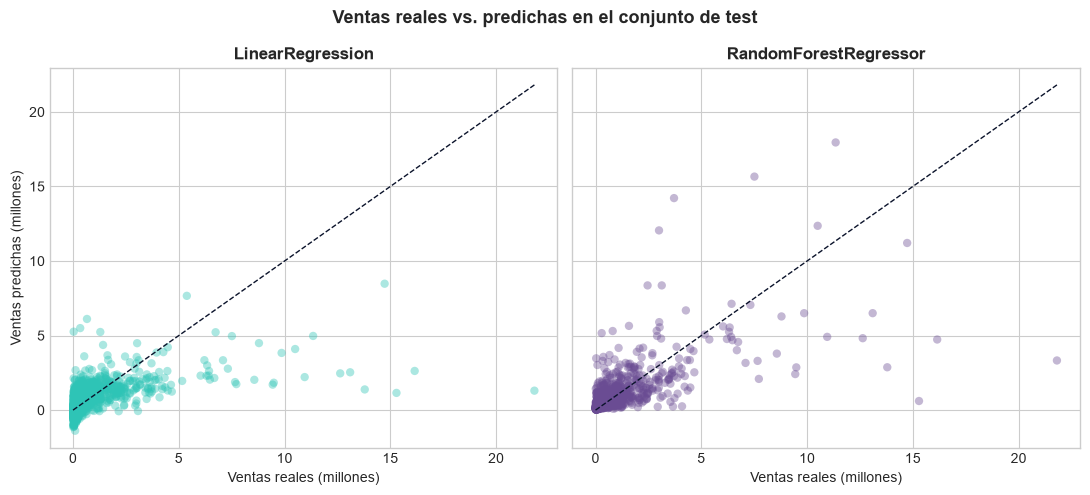

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

max_val = max(y_test.max(), y_pred_lineal.max(), y_pred_rf.max())

for ax, y_pred, titulo, color in zip(
    axes,
    [y_pred_lineal, y_pred_rf],
    ["LinearRegression", "RandomForestRegressor"],
    ["#2EC4B6", "#6A4C93"],
):
    ax.scatter(y_test, y_pred, alpha=0.4, color=color, edgecolor="none")
    ax.plot([0, max_val], [0, max_val], color="#0B132B", linewidth=1, linestyle="--")
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("Ventas reales (millones)")

axes[0].set_ylabel("Ventas predichas (millones)")
fig.suptitle("Ventas reales vs. predichas en el conjunto de test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Interpretacion de resultados

| Modelo | MAE | RMSE | R2 |
|---|---|---|---|
| LinearRegression | 0.71 | 1.40 | 0.276 |
| RandomForestRegressor | 0.52 | 1.26 | 0.416 |

**RandomForestRegressor** obtiene mejor desempeno que la regresion lineal en las tres metricas: se
equivoca en promedio por menos millones de copias (MAE 0.52 vs. 0.71) y explica una porcion mayor de
la variabilidad de las ventas (R2 0.416 vs. 0.276). Esto sugiere que la relacion entre las features
(critica, plataforma, genero, rating, anio) y las ventas **no es puramente lineal** - hay
combinaciones (por ejemplo, un genero especifico en una plataforma especifica) que un modelo lineal
no puede capturar y un arbol si.

Puesto en contexto del problema real (ventas de videojuegos):

- Un **R2 de ~0.42** es modesto: el modelo explica menos de la mitad de la variabilidad de las
  ventas. Esto es esperable, porque el dataset no incluye factores clave que sabemos que mueven las
  ventas de un juego (presupuesto de marketing, fuerza de la franquicia, exclusividad de consola,
  fecha de lanzamiento respecto a la competencia). `critic_score`, `platform` y `genre` ayudan, pero
  no alcanzan para explicar del todo por que un juego vende mucho o poco.
- El **RMSE (1.26M) es bastante mayor que el MAE (0.52M)** en ambos modelos. Esto es consistente con
  lo que ya habia mostrado el EDA: las ventas estan muy concentradas en pocos "blockbusters" (hasta
  82M de copias) frente a una mediana muy baja (0.08-0.17M). Esos pocos casos extremos generan
  errores grandes que inflan el RMSE mucho mas que el MAE.
- En terminos practicos, el modelo sirve como una **estimacion aproximada** de cuanto podria vender
  un juego a partir de su recepcion critica y sus caracteristicas basicas (plataforma, genero,
  rating, anio), pero no deberia usarse para anticipar con precision los proximos "exitos masivos":
  al estar entrenado sobre una distribucion tan sesgada, tiende a subestimar los casos extremos.
- Solo se pudo entrenar con **6.826 de las 16.717 filas** del dataset (el resto no tenia
  `critic_score`/`user_score`), por lo que el modelo esta sesgado hacia juegos que Metacritic si
  reseno - probablemente los mas relevantes o de mayor presupuesto, algo que ya habia anticipado el
  EDA al analizar los faltantes.

La optimizacion de hiperparametros (`n_estimators`, profundidad maxima del arbol, regularizacion,
etc.) y la posible mejora del modelo quedan para la Tercera Evidencia.